# Day 4: Evaluation & Hyperparameter Tuning
Confusion matrix, precision/recall/F1, ROC-AUC for both models; GridSearchCV tuning on XGBoost.


In [5]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
DATA_PATH = Path("../data/processed/telco_churn_processed.csv")
df = pd.read_csv(DATA_PATH)

X = df.drop(columns = ["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

scaler = joblib.load("../outputs/models/scaler.joblib")
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "TotalServices"]
X_train[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

log_reg = joblib.load("../outputs/models/logistic_regression.joblib")
xgb_model = joblib.load("../outputs/models/xgboost.joblib")

print("Loaded models and data. Test shape:", X_test.shape)


Loaded models and data. Test shape: (1409, 27)


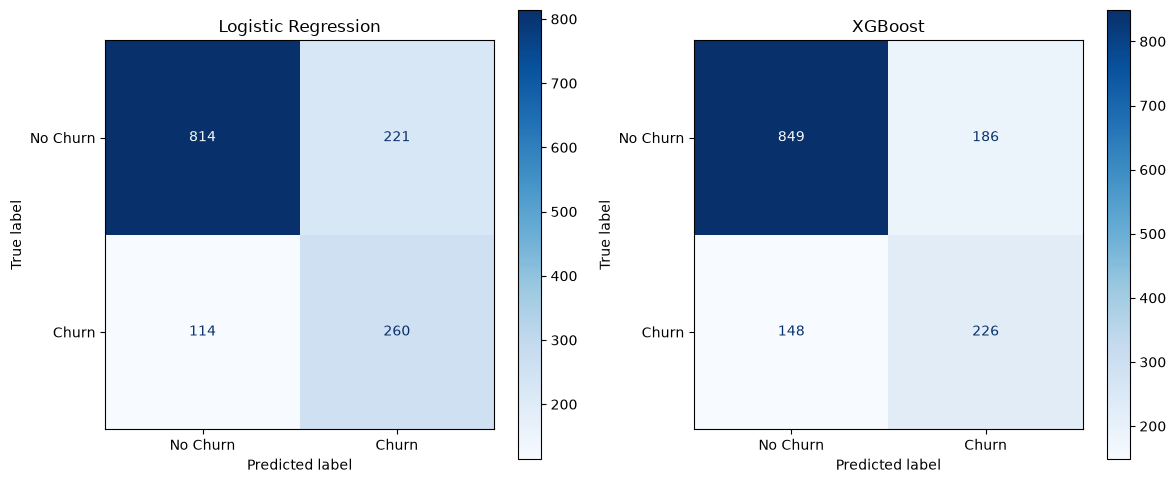

In [8]:
#confusion matrix will made which will provide 4 outcomes - True N, True P, False N(expensive mistake), False P

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(1,2,figsize=(12, 5))
for ax, model, name in zip(axes, [log_reg, xgb_model], ["Logistic Regression", "XGBoost"]):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels = ["No Churn", "Churn"]).plot(ax = ax, cmap = "Blues")
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../outputs/plots/confusion_matrices.png", dpi = 150)
plt.show()

In [18]:
#precision - model predicted will churn , what fraction actually did churn
#recall - who actually churned, what fraction model catch (important)
#F1 - harmonic mean of precision and recall 

from sklearn.metrics import classification_report

for model, name in [(log_reg, "Logistic Regression"), (xgb_model, "XGBoost")]:
    y_pred = model.predict(X_test)
    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred, target_names = ["No Churn", "Churn"]))


--- Logistic Regression ---
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.70      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409


--- XGBoost ---
              precision    recall  f1-score   support

    No Churn       0.85      0.82      0.84      1035
       Churn       0.55      0.60      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.71      1409
weighted avg       0.77      0.76      0.77      1409



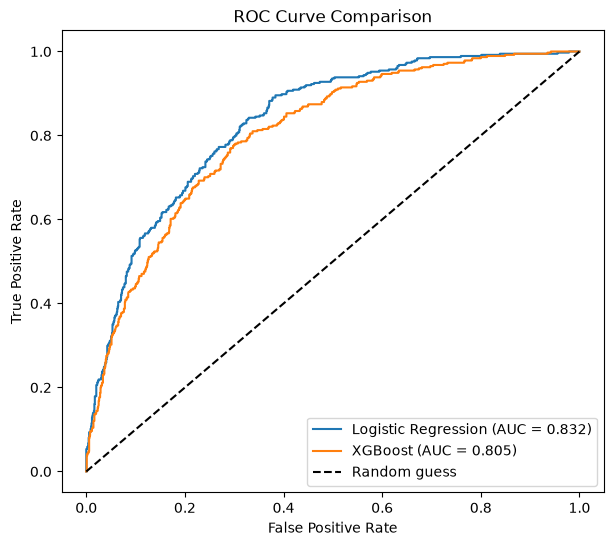

In [19]:
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize = (7, 6))

for model, name in [(log_reg, "Logistic Regression"), (xgb_model, "XGBoost")]:
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label = f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], "k--", label = "Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../outputs/plots/roc_curve.png", dpi = 150)
plt.show()

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
from xgboost import XGBClassifier

param_grid = {"max_depth" : [3,5,7], "learning_rate" : [0.01, 0.1, 0.3], "n_estimators" : [100,200,300]}

recall_scorer = make_scorer(recall_score, pos_label = 1)
xgb_base = XGBClassifier(random_state = 42, eval_metric = "logloss")

grid_search = GridSearchCV(xgb_base, param_grid, scoring = recall_scorer, cv = 3, n_jobs=-1, verbose=1)

grid_search.fit(X_train_smote, y_train_smote)

print("Best params:", grid_search.best_params_)
print("Best CV recall:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Best CV recall: 0.8381


In [23]:
#above result is not on the actual test data
#now evaluating tuned model on actual test set 

best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("--- Tuned XGBoost (Test Set) ---")
print(classification_report(y_test, y_pred_tuned, target_names= [ "No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_tuned), 4))

--- Tuned XGBoost (Test Set) ---
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409

ROC-AUC: 0.8358
